

ОБУЧЕНИЕ k-NN КЛАССИФИКАТОРОВ
Загрузка данных (90% обучение / 10% тест)...
Найдено классов: 21
Классы: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'x', 'h', 't', '×', 'w', 'y']
  '(': train=12864, test=1430
  ')': train=12919, test=1436
  '+': train=22600, test=2512
  ',': train=1715, test=191
  '-': train=30597, test=3400
  '0': train=6222, test=692
  '1': train=23868, test=2652
  '2': train=23526, test=2615
  '3': train=9818, test=1091
  '4': train=6656, test=740
  '5': train=3190, test=355
  '6': train=2806, test=312
  '7': train=2618, test=291
  '8': train=2761, test=307
  '9': train=565, test=63
  'x': train=23934, test=2660
  'h': train=1317, test=147
  't': train=2946, test=328
  '×': train=2925, test=326
  'w': train=500, test=56
  'y': train=8406, test=934

Всего обучающих образцов: 202753
Всего тестовых образцов: 22538
Размерность вектора: 2025

ОБУЧЕНИЕ КЛАССИФИКАТОРОВ k-NN
Обучение модели k=1...
Обучение модели k=3...
Обучение модели k=5...

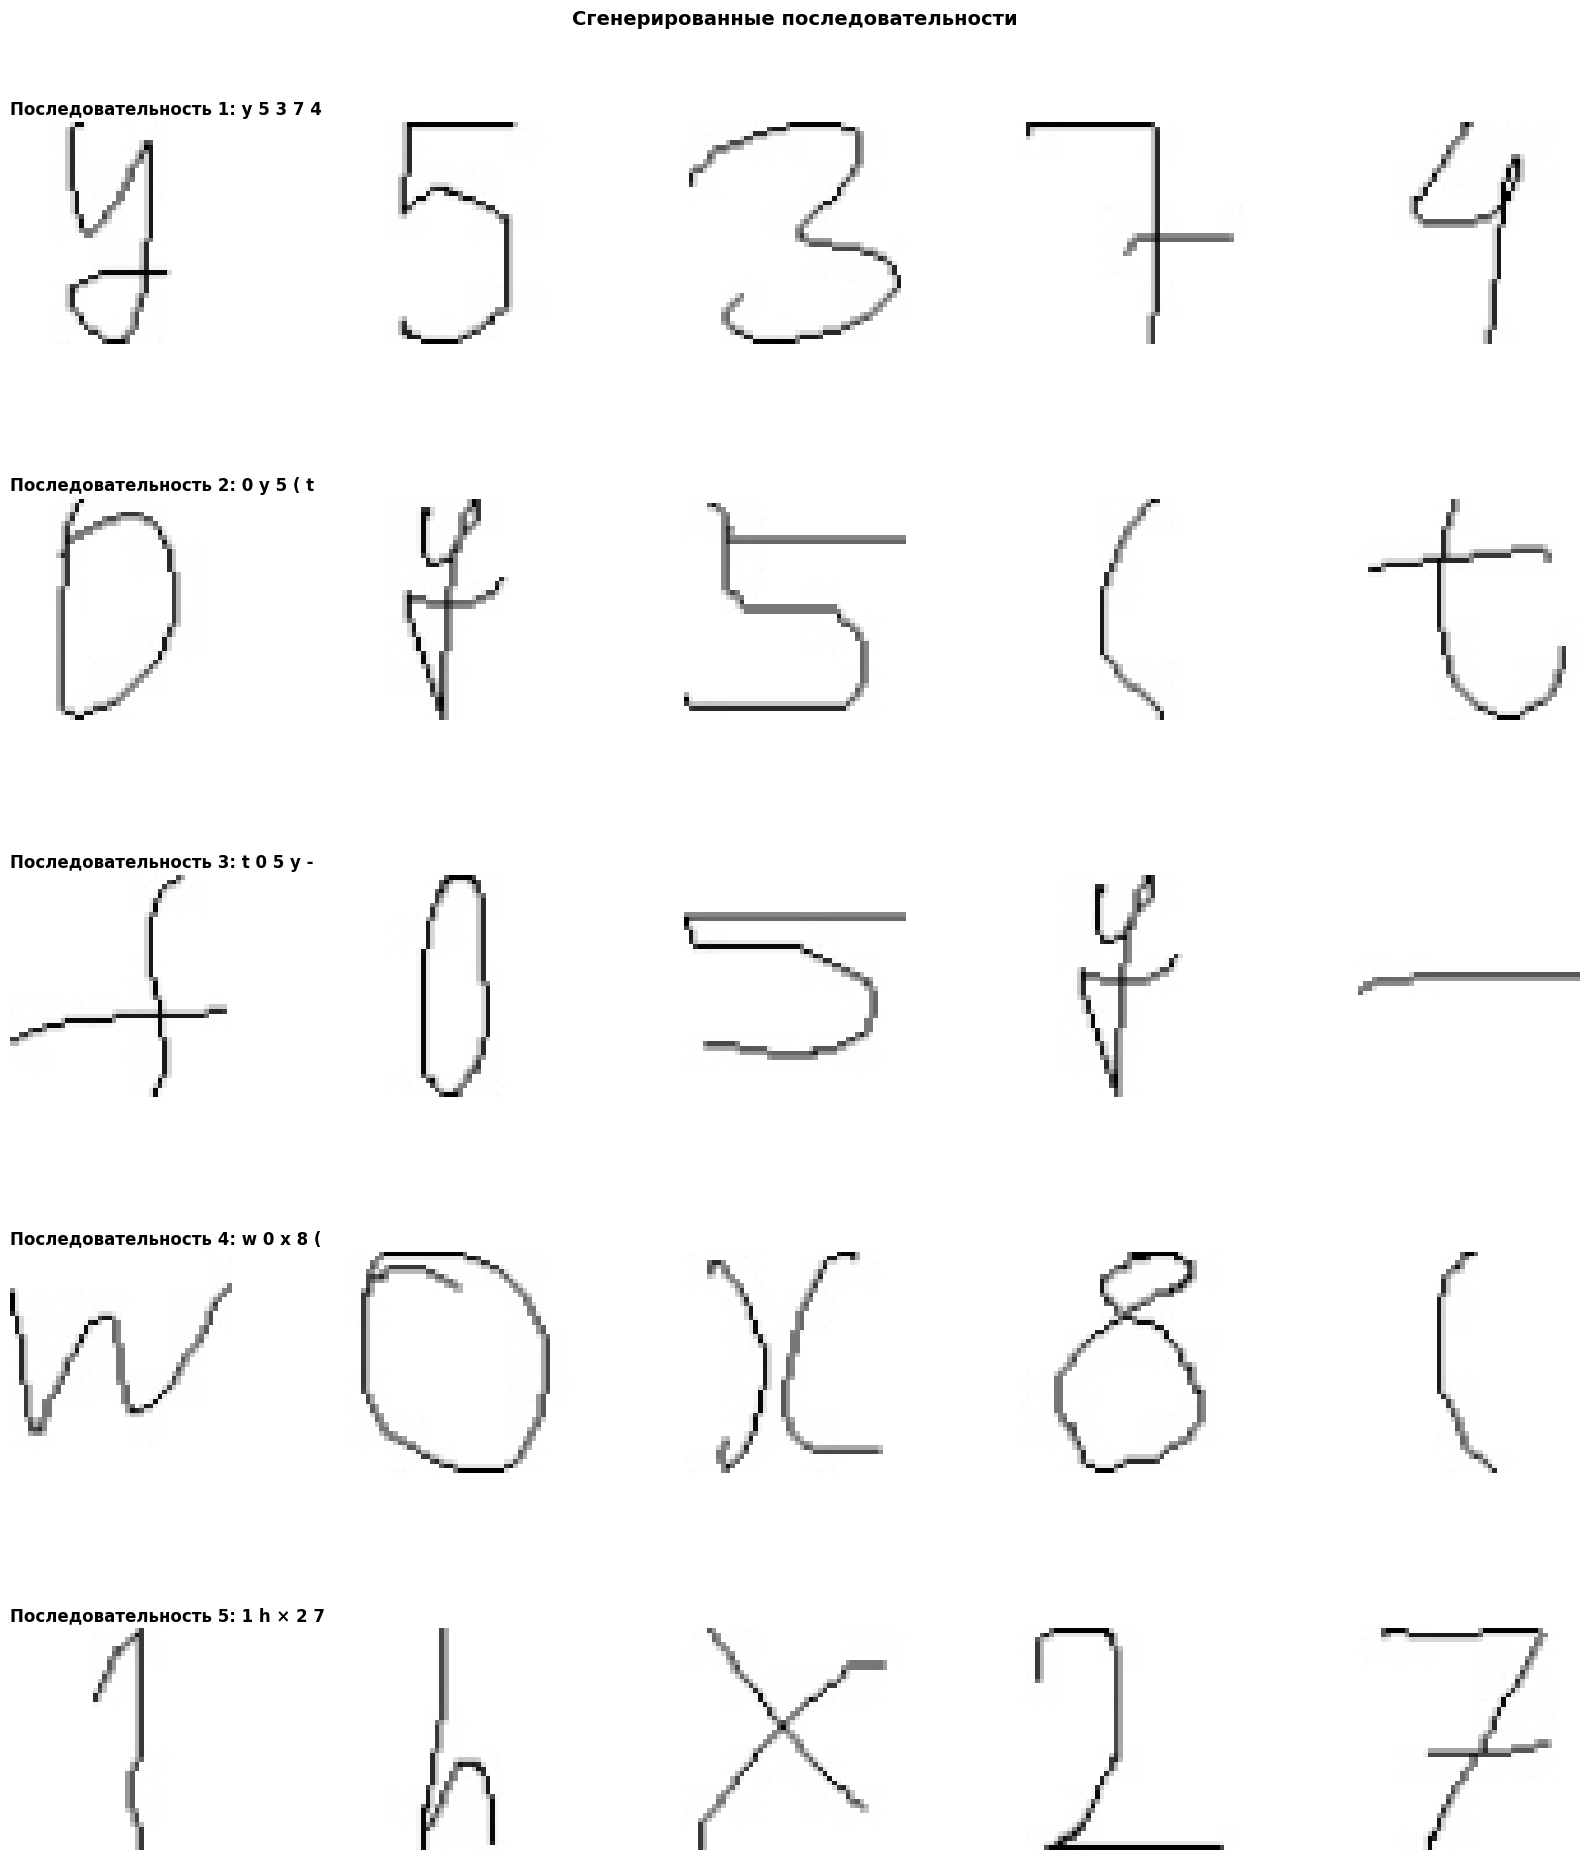


Сгенерировано 5 последовательностей
РАСПОЗНАВАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ


Последовательность 1: 'y 5 3 7 4'
  knn1: 'y5374' | 100.0% 
  knn3: 'y53t4' |  80.0% 
  knn5: 'y53t4' |  80.0% 
  knn7: 'y53t4' |  80.0% 


Последовательность 2: '0 y 5 ( t'
  knn1: '0y5(+-' |  80.0% 
  knn3: '0y5(+-' |  80.0% 
  knn5: '0y2(+-' |  60.0% 
  knn7: '0y2(+-' |  60.0% 


Последовательность 3: 't 0 5 y -'
  knn1: 't05y-' | 100.0% 
  knn3: 't0ty-' |  80.0% 
  knn5: 't0ty-' |  80.0% 
  knn7: 't0ty-' |  80.0% 


Последовательность 4: 'w 0 x 8 ('
  knn1: 'w0)(8(' |  40.0% 
  knn3: 'w0)(3(' |  40.0% 
  knn5: 'w0)(3(' |  40.0% 
  knn7: 'w0)(3(' |  40.0% 


Последовательность 5: '1 h × 2 7'
  knn1: '1h×27' | 100.0% 
  knn3: '1h×27' | 100.0% 
  knn5: '1h×27' | 100.0% 
  knn7: '1h×27' | 100.0% 
ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ МОДЕЛЯМ

knn1:
  Полное совпадение: 3/5 (60.0%)
  Посимвольная точность: 21/25 (84.0%)

knn3:
  Полное совпадение: 1/5 (20.0%)
  Посимвольная точность: 19/25 (76.0%)

knn5:
  Полное совпадение:

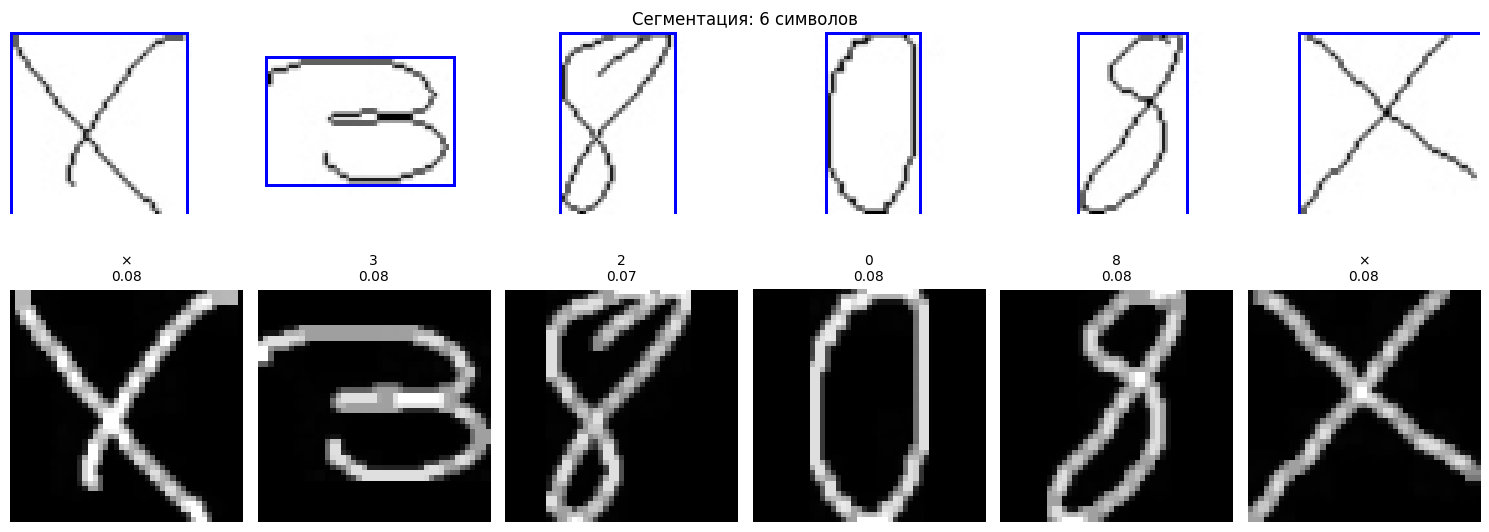

Распознанный текст: '×3208×'
Символов: 6
Средняя уверенность: 0.080


In [1]:
import cv2
import numpy as np
import os
import random
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt



class CharacterKNNClassifier:
        
    def __init__(self, data_folder='./data', image_size=45, train_ratio=0.9):
        self.data_folder = data_folder
        self.image_size = image_size
        self.train_ratio = train_ratio
        self.classifiers = {}
        self.char_labels = []
        self.label_to_char = {}
        self.char_to_label = {}
        self.X_train = []
        self.y_train = []
        self.X_test = []
        self.y_test = []
    
    def load_training_data(self):
        
        print("Загрузка данных (90% обучение / 10% тест)...")
        
        name_folders = []
        folder_names = []
        
        for item in sorted(os.listdir(self.data_folder)):
            item_path = os.path.join(self.data_folder, item)
            if os.path.isdir(item_path):
                folder_names.append(item)
                if item == 'times':
                    name_folders.append('×')
                elif item == 'X':
                    name_folders.append('x')
                else:
                    name_folders.append(item)
        
        self.char_labels = name_folders
        
        for idx, char in enumerate(self.char_labels):
            self.label_to_char[idx] = char
            self.char_to_label[char] = idx
        
        print(f"Найдено классов: {len(self.char_labels)}")
        print(f"Классы: {self.char_labels}")
        
        X_train_list = []
        y_train_list = []
        X_test_list = []
        y_test_list = []
        
        for folder_name, char in zip(folder_names, self.char_labels):
            folder_path = os.path.join(self.data_folder, folder_name)
            label = self.char_to_label[char]
            
            images = []
            for img_file in sorted(os.listdir(folder_path)):
                if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    continue
                img_path = os.path.join(folder_path, img_file)
                images.append(img_path)
            
            split_idx = int(len(images) * self.train_ratio)
            train_images = images[:split_idx]
            test_images = images[split_idx:]
            
            for img_path in train_images:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = self._preprocess_for_training(img)
                    X_train_list.append(img.flatten())
                    y_train_list.append(label)
            
            for img_path in test_images:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = self._preprocess_for_training(img)
                    X_test_list.append(img.flatten())
                    y_test_list.append(label)
            
            print(f"  '{char}': train={len(train_images)}, test={len(test_images)}")
        
        self.X_train = np.array(X_train_list)
        self.y_train = np.array(y_train_list)
        self.X_test = np.array(X_test_list)
        self.y_test = np.array(y_test_list)
        
        print(f"\nВсего обучающих образцов: {len(self.X_train)}")
        print(f"Всего тестовых образцов: {len(self.X_test)}")
        print(f"Размерность вектора: {self.X_train.shape[1]}")
    
    def _center_in_square(self, image, target_size):
        h, w = image.shape
        if h > target_size or w > target_size:
            scale = target_size / max(h, w)
            new_h = int(h * scale)
            new_w = int(w * scale)
            image = cv2.resize(image, (new_w, new_h))
            h, w = new_h, new_w
        squared = np.zeros((target_size, target_size), dtype=np.uint8)
        y_offset = (target_size - h) // 2
        x_offset = (target_size - w) // 2
        squared[y_offset:y_offset+h, x_offset:x_offset+w] = image
        squared = squared.astype(np.float32) / 255.0
        return squared

    def _preprocess_for_training(self, img):
        img = cv2.bitwise_not(img)
        img = self._center_in_square(img, self.image_size)
        return img
    
    def train_multiple_k(self, k_values=[1, 3, 5, 7]):
        
        print("\nОБУЧЕНИЕ КЛАССИФИКАТОРОВ k-NN")
                
        for k in k_values:
            print(f"Обучение модели k={k}...")
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(self.X_train, self.y_train)
            self.classifiers[f'knn{k}'] = knn
            
            y_pred = knn.predict(self.X_test)
            accuracy = accuracy_score(self.y_test, y_pred)
            
        
        print("\nВсе модели обучены!")
    
    def evaluate_all(self):
        
        print("ОЦЕНКА ВСЕХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
        
        
        results = {}
        
        for model_name, classifier in self.classifiers.items():
            y_pred = classifier.predict(self.X_test)
            accuracy = accuracy_score(self.y_test, y_pred)
            results[model_name] = accuracy
            print(f"{model_name}: accuracy = {accuracy:.4f}")
        
        best_model = max(results.items(), key=lambda x: x[1])
        print(f"\nЛучшая модель: {best_model[0]} с accuracy={best_model[1]:.4f}")
        
        return results
    
    def predict_char(self, image, model_name='knn3'):
        
        if model_name not in self.classifiers:
            raise ValueError(f"Модель {model_name} не найдена!")
        
        feature_vector = image.flatten().reshape(1, -1)
        
        label = self.classifiers[model_name].predict(feature_vector)[0]
        char = self.label_to_char[label]
        
        distances, _ = self.classifiers[model_name].kneighbors(feature_vector)
        confidence = 1.0 / (1.0 + np.mean(distances))
        
        return char, confidence
    
    def save_models(self, filepath='knn_models.pkl'):
        model_data = {
            'classifiers': self.classifiers,
            'char_labels': self.char_labels,
            'label_to_char': self.label_to_char,
            'char_to_label': self.char_to_label,
            'image_size': self.image_size
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"\nВсе модели сохранены: {filepath}")
    
    def load_models(self, filepath='knn_models.pkl'):
        
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        
        self.classifiers = model_data['classifiers']
        self.char_labels = model_data['char_labels']
        self.label_to_char = model_data['label_to_char']
        self.char_to_label = model_data['char_to_label']
        self.image_size = model_data['image_size']
        
        print(f"Модели загружены: {filepath}")



class HandwrittenSequenceGenerator:
    
    
    def __init__(self, data_folder='./data', output_folder='./generated_sequences', 
                 test_ratio=0.1, verbose=True):
        self.data_folder = data_folder
        self.output_folder = output_folder
        self.test_ratio = test_ratio
        self.verbose = verbose
        self.char_images = {}
        self.char_labels = []
        
        os.makedirs(output_folder, exist_ok=True)
        self._load_test_images()
    
    def _load_test_images(self):
        
        if self.verbose:
            print("Загрузка тестовых изображений (последние 10%)...")
        
        for item in sorted(os.listdir(self.data_folder)):
            item_path = os.path.join(self.data_folder, item)
            if not os.path.isdir(item_path):
                continue
            
            if item == 'times':
                char = '×'
            elif item == 'X':
                char = 'x'
            else:
                char = item
            
            self.char_labels.append(char)
            
            image_paths = []
            for img_file in sorted(os.listdir(item_path)):
                if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    continue
                image_paths.append(os.path.join(item_path, img_file))
            
            split_idx = int(len(image_paths) * (1 - self.test_ratio))
            test_images_paths = image_paths[split_idx:]
            
            images = []
            for img_path in test_images_paths:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    images.append(img)
            
            self.char_images[char] = images
            
            if self.verbose:
                print(f"  '{char}': {len(images)} тестовых изображений")
        
        if self.verbose:
            print(f"\nВсего символов: {len(self.char_labels)}")
    
    def generate_random_text_with_spaces(self, length=5):
        
        available = [c for c in self.char_labels if len(self.char_images.get(c, [])) > 0]
        
        if not available:
            raise ValueError("Нет доступных символов!")
        
        
        chars = [random.choice(available) for _ in range(length)]
        
        
        text_with_spaces = ' '.join(chars)
        
        return text_with_spaces
    
    def create_char_image(self, char, target_height=48):
        
        if char not in self.char_images or len(self.char_images[char]) == 0:
            return np.zeros((target_height, target_height), dtype=np.uint8)
        
        img = random.choice(self.char_images[char]).copy()
        
        h, w = img.shape
        scale = target_height / h
        new_w = int(w * scale)
        img_resized = cv2.resize(img, (new_w, target_height))
        
        return img_resized
    
    def create_sequence_image(self, text, char_height=48, space_width=25):
       
        images = []
        for char in text:
            if char == ' ':
                
                space_img = np.ones((char_height, space_width), dtype=np.uint8) * 255
                images.append(space_img)
            else:
                img = self.create_char_image(char, char_height)
                images.append(img)
        
        
        total_width = sum(img.shape[1] for img in images)
        max_height = max(img.shape[0] for img in images)
        
       
        sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255
        
        x_offset = 0
        for img in images:
            h, w = img.shape
            y_offset = (max_height - h)
            sequence_img[y_offset:y_offset+h, x_offset:x_offset+w] = img
            x_offset += w
        
        return sequence_img
    
    def generate_dataset(self, num_samples=5, seq_length=5):
        
        dataset = []
        
        if self.verbose:
            print(f"\nГенерация {num_samples} последовательностей ...")
        
        for i in range(num_samples):
            
            text = self.generate_random_text_with_spaces(length=seq_length)
            
            img = self.create_sequence_image(text)
            
            img_path = os.path.join(self.output_folder, f'seq_{i:04d}.png')
            cv2.imwrite(img_path, img)
            
            dataset.append({
                'text': text,
                'text_no_spaces': text.replace(' ', ''),  
                'image_path': img_path
            })
            
            if self.verbose:
                print(f"  {i+1}. '{text}'")
        
        if self.verbose:
            print(f"Готово! Сохранено в {self.output_folder}")
        
        return dataset




class SequenceRecognizer:
    
    
    def __init__(self, classifier):
        self.classifier = classifier
    
    def segment_characters(self, image, min_area=50):
        
        if len(image.shape) == 3:
            img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = image.copy()
        
        
        kernel = np.ones((3, 3), np.uint8)
        img_eroded = cv2.erode(img_gray, kernel, iterations=1)
        
       
        img_inverted = cv2.bitwise_not(img_eroded)
        
        
        ret, thresh = cv2.threshold(img_inverted, 127, 255, 0)
        
        
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        crops = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w * h > min_area:
                char_img = img_inverted[y:y+h, x:x+w]
                crops.append((x, y, w, h, char_img))
        
       
        crops.sort(key=lambda c: c[0])
        
        return crops
    
    def center_in_square(self, image, target_size=45):
        
        h, w = image.shape
        
        
        if h > target_size or w > target_size:
            scale = target_size / max(h, w)
            new_h = int(h * scale)
            new_w = int(w * scale)
            image = cv2.resize(image, (new_w, new_h))
            h, w = new_h, new_w
        
        
        squared = np.zeros((target_size, target_size), dtype=np.uint8)
        y_offset = (target_size - h) // 2
        x_offset = (target_size - w) // 2
        squared[y_offset:y_offset+h, x_offset:x_offset+w] = image
        
        
        squared = squared.astype(np.float32) / 255.0
        
        return squared
    
    def recognize_sequence(self, image, model_name='knn3', visualize=False):
        
        crops = self.segment_characters(image)
        
        if len(crops) == 0:
            print("Предупреждение: символы не найдены!")
            return "", []
        
        if visualize:
            if len(image.shape) == 2:
                img_vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
            else:
                img_vis = image.copy()
            
            
            for (x, y, w, h, _) in crops:
                cv2.rectangle(img_vis, (x, y), (x+w, y+h), (255, 0, 0), 1)
            
            n_chars = len(crops)
            fig = plt.figure(figsize=(15, 6))
            
            ax1 = plt.subplot(2, max(n_chars, 1), (1, n_chars))
            ax1.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
            ax1.set_title(f'Сегментация: {n_chars} символов', fontsize=12)
            ax1.axis('off')
        
        recognized_chars = []
        confidences = []
        
        for i, (x, y, w, h, char_img) in enumerate(crops):
            char_img_preprocessed = self.center_in_square(char_img, 45)
            
            char, confidence = self.classifier.predict_char(char_img_preprocessed, model_name)
            recognized_chars.append(char)
            confidences.append(confidence)
            
            if visualize:
                ax = plt.subplot(2, n_chars, n_chars + i + 1)
                display_img = (char_img_preprocessed * 255).astype(np.uint8)
                ax.imshow(display_img, cmap='gray')
                ax.set_title(f'{char}\n{confidence:.2f}', fontsize=10)
                ax.axis('off')
        
        if visualize:
            plt.tight_layout()
            plt.show()
        
        text = ''.join(recognized_chars)
        
        return text, confidences
    
    def recognize_from_file(self, image_path, model_name='knn3', visualize=True):
        
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            raise ValueError(f"Не удалось загрузить: {image_path}")
        
        print(f"\nРаспознавание: {image_path}")
        text, confidences = self.recognize_sequence(img, model_name, visualize)
        
        avg_confidence = np.mean(confidences) if confidences else 0
        
        print(f"Распознанный текст: '{text}'")
        print(f"Символов: {len(text)}")
        print(f"Средняя уверенность: {avg_confidence:.3f}")
        
        return text, confidences




def step1_train_knn():
    
    print("\n")
    print("ОБУЧЕНИЕ k-NN КЛАССИФИКАТОРОВ")
    
    
    classifier = CharacterKNNClassifier(data_folder='./data', image_size=45, train_ratio=0.9)
    classifier.load_training_data()
    
    classifier.train_multiple_k(k_values=[1, 3, 5, 7])
    results = classifier.evaluate_all()
    classifier.save_models('knn_models.pkl')
    
    return classifier


def step2_generate_sequences():
    print("\n")
    print("ГЕНЕРАЦИЯ ТЕСТОВЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")
    
    
    generator = HandwrittenSequenceGenerator(
        data_folder='./data',
        output_folder='./test_sequences',
        test_ratio=0.1,
        verbose=True
    )
    
    dataset = generator.generate_dataset(num_samples=5, seq_length=5)
    
    
    fig, axes = plt.subplots(5, 1, figsize=(16, 20))
    
    for i in range(len(dataset)):
        img = cv2.imread(dataset[i]['image_path'], cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Последовательность {i+1}: {dataset[i]['text']}", 
                         fontsize=12, fontweight='bold', loc='left')
        axes[i].axis('off')
    
    plt.suptitle('Сгенерированные последовательности', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('test_sequences_examples.png', dpi=150, bbox_inches='tight')
    print("\nИзображение сохранено: test_sequences_examples.png")
    plt.show()
    
    print(f"\nСгенерировано {len(dataset)} последовательностей")
    return dataset


def step3_recognize_sequences(classifier, dataset):
      
    print("РАСПОЗНАВАНИЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")
    
    
    recognizer = SequenceRecognizer(classifier)
    
    model_names = list(classifier.classifiers.keys())
    all_results = {model: {'correct': 0, 'total': 0, 'correct_chars': 0, 'total_chars': 0} 
                   for model in model_names}
    
    for i, sample in enumerate(dataset):
        img = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)
        true_text = sample['text']
        true_text_no_spaces = sample['text_no_spaces']
        
        print(f"\n")
        print(f"Последовательность {i+1}: '{true_text}'")
        
        
        for model_name in model_names:
            text, confidences = recognizer.recognize_sequence(img, model_name, visualize=False)
            
            
            is_correct = (text == true_text_no_spaces)
            if is_correct:
                all_results[model_name]['correct'] += 1
            all_results[model_name]['total'] += 1
            
            for j in range(min(len(true_text_no_spaces), len(text))):
                if true_text_no_spaces[j] == text[j]:
                    all_results[model_name]['correct_chars'] += 1
            all_results[model_name]['total_chars'] += len(true_text_no_spaces)
            
            char_acc = sum(1 for t, p in zip(true_text_no_spaces, text) if t == p) / len(true_text_no_spaces) if len(true_text_no_spaces) > 0 else 0

            
            print(f"  {model_name}: '{text}' | {char_acc:>6.1%} ")
    
    
    print("ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ МОДЕЛЯМ")
    
    
    for model_name in sorted(model_names):
        res = all_results[model_name]
        full_acc = res['correct'] / res['total'] if res['total'] > 0 else 0
        char_acc = res['correct_chars'] / res['total_chars'] if res['total_chars'] > 0 else 0
        
        print(f"\n{model_name}:")
        print(f"  Полное совпадение: {res['correct']}/{res['total']} ({full_acc:.1%})")
        print(f"  Посимвольная точность: {res['correct_chars']}/{res['total_chars']} ({char_acc:.1%})")
    
    return all_results


def step4_test_custom(classifier):
    print("\n")
    print("ТЕСТ НА СГЕНЕРИРОВАННОМ ИЗОБРАЖЕНИИ")
    
    
    recognizer = SequenceRecognizer(classifier)
    
    generator = HandwrittenSequenceGenerator(data_folder='./data', test_ratio=0.1, verbose=False)
    test_text = generator.generate_random_text_with_spaces(length=6)
    test_text_no_spaces = test_text.replace(' ', '')
    img = generator.create_sequence_image(test_text, char_height=60)
    
    cv2.imwrite('test_custom.png', img)
    print(f"Создано изображение: test_custom.png")
    print(f"Истинный текст: '{test_text}'")
    
    
    
    print("nРАСПОЗНАВАНИЕ ВСЕМИ МОДЕЛЯМИ:")
    
    
    for model_name in sorted(classifier.classifiers.keys()):
        print(f"\n{model_name}:")
        text, conf = recognizer.recognize_from_file('test_custom.png', model_name, visualize=False)
        
        is_correct = (text == test_text_no_spaces)
        char_acc = sum(1 for t, p in zip(test_text_no_spaces, text) if t == p) / len(test_text_no_spaces) if len(test_text_no_spaces) > 0 else 0

        print(f"  Посимвольная точность: {char_acc:.1%}")
    
    print(f"\nВизуализация с моделью knn3:")
    recognizer.recognize_from_file('test_custom.png', 'knn3', visualize=True)
    




def main():
    
    
    classifier = step1_train_knn()
    dataset = step2_generate_sequences()
    all_results = step3_recognize_sequences(classifier, dataset)
    step4_test_custom(classifier)
    
   




if __name__ == "__main__":
    main()
